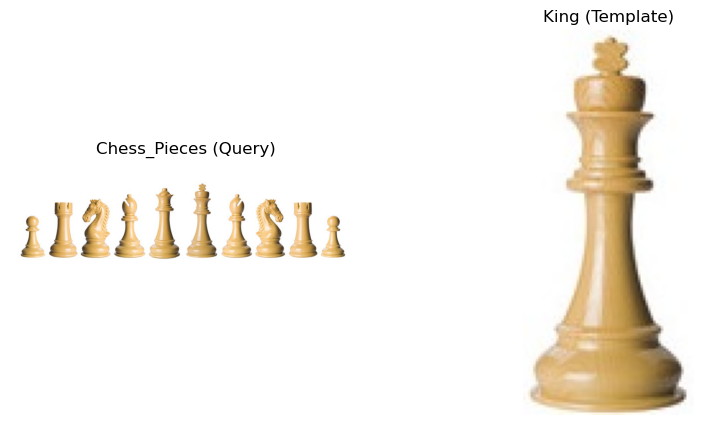

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the query and template images
query_img_color = cv2.imread("Assignment3_Files/Chess_Pieces.jpg")
template_img_color = cv2.imread("Assignment3_Files/King.jpg")

# Convert to grayscale
query_gray = cv2.cvtColor(query_img_color, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_img_color, cv2.COLOR_BGR2GRAY)

# Get dimensions of the template
t_h, t_w = template_gray.shape[:2]

# Display the images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(query_img_color, cv2.COLOR_BGR2RGB))
plt.title('Chess_Pieces (Query)')
plt.axis('off')

plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(template_img_color, cv2.COLOR_BGR2RGB))
plt.title('King (Template)')
plt.axis('off')
plt.show()


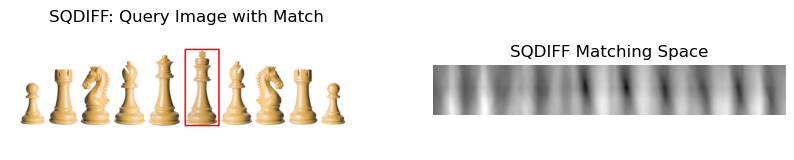

In [2]:
# Perform template matching
result_sqdiff = cv2.matchTemplate(query_gray, template_gray, cv2.TM_SQDIFF)

# Normalize result for visualization
# This scales the result into [0,1] range
cv2.normalize(result_sqdiff, result_sqdiff, 0, 1, cv2.NORM_MINMAX, -1)

# The best match location for TM_SQDIFF is where the result is MINIMUM
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result_sqdiff)

top_left_sqdiff = min_loc  # Because SQDIFF uses min_loc
bottom_right_sqdiff = (top_left_sqdiff[0] + t_w, top_left_sqdiff[1] + t_h)

# Draw the rectangle on a copy of the query image
query_img_sqdiff = query_img_color.copy()
cv2.rectangle(query_img_sqdiff, top_left_sqdiff, bottom_right_sqdiff, (0, 0, 255), 2)

# Show the result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("SQDIFF: Query Image with Match")
plt.imshow(cv2.cvtColor(query_img_sqdiff, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("SQDIFF Matching Space")
plt.imshow(result_sqdiff, cmap='gray')
plt.axis('off')

plt.show()


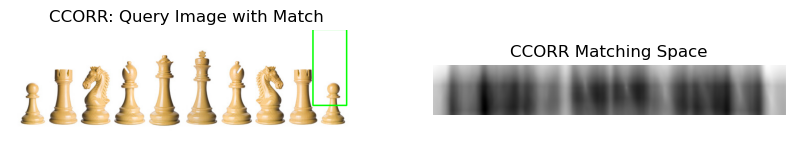

In [9]:
# Perform template matching with TM_CCORR
result_ccorr = cv2.matchTemplate(query_gray, template_gray, cv2.TM_CCORR)

# Normalize for visualization (optional)
cv2.normalize(result_ccorr, result_ccorr, 0, 1, cv2.NORM_MINMAX, -1)

# The best match location for TM_CCORR is where the result is MAXIMUM
min_val_c, max_val_c, min_loc_c, max_loc_c = cv2.minMaxLoc(result_ccorr)

top_left_ccorr = max_loc_c  # Because CCORR uses max_loc
bottom_right_ccorr = (top_left_ccorr[0] + t_w, top_left_ccorr[1] + t_h)

# Draw rectangle
query_img_ccorr = query_img_color.copy()
cv2.rectangle(query_img_ccorr, top_left_ccorr, bottom_right_ccorr, (0, 255, 0), 2)

# Show the result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("CCORR: Query Image with Match")
plt.imshow(cv2.cvtColor(query_img_ccorr, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("CCORR Matching Space")
plt.imshow(result_ccorr, cmap='gray')
plt.axis('off')

plt.show()
